#**Assignment 3: Exploratory Data Analysis**


In [2]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [3]:
! mkdir "/content/gdrive/My Drive/Colab Notebooks/data"

mkdir: cannot create directory ‘/content/gdrive/My Drive/Colab Notebooks/data’: File exists


## Install and Import Required Libraries
We install the ChEMBL web service package so that we can retrieve bioactivity data

In [4]:
!pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00


# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')
from chembl_webresource_client.new_client import new_client

# Step 1: Search for Traget Protein

## **Target Identification (BRCA1)**
Search ChEMBL for the KRAS target and select the most relevant entry.


In [6]:
target = new_client.target
target_query = target.search("BRCA1")
targets = pd.DataFrame.from_dict(target_query)
targets.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,Breast cancer type 1 susceptibility protein,19.0,False,CHEMBL5990,"[{'accession': 'P38398', 'component_descriptio...",SINGLE PROTEIN,9606
1,[],Homo sapiens,Lys-63-specific deubiquitinase BRCC36,19.0,False,CHEMBL4105965,"[{'accession': 'P46736', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Homo sapiens,BRCA1-associated protein,18.0,False,CHEMBL5291566,"[{'accession': 'Q7Z569', 'component_descriptio...",SINGLE PROTEIN,9606
3,[],Homo sapiens,Ubiquitin carboxyl-terminal hydrolase BAP1,15.0,False,CHEMBL1293314,"[{'accession': 'Q92560', 'component_descriptio...",SINGLE PROTEIN,9606


**Reterive Bioactivity data for selected target**

In [7]:
selected_target = targets.target_chembl_id[0]
selected_target

'CHEMBL5990'

**Now retrieve only bioactivity data for target; **BRCA1(CHEMBL5990)** with reported IC 50  values in nM (nanomolar) unit.**

In [8]:
activity = new_client.activity
results = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

In [9]:
df1 = pd.DataFrame.from_dict(results)
df1.head(5)

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,6222842,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,4.6
1,None,None,6222843,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,250.0
2,None,None,6222844,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,52.8
3,None,None,6222845,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,250.0
4,None,None,6222846,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,15.0


In [10]:
df1.standard_type.unique()

array(['IC50'], dtype=object)

In [11]:
df1.to_csv('bioactivity_raw_data.csv', index=False)

In [12]:
! cp bioactivity_raw_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"

In [13]:
! ls -l "/content/gdrive/My Drive/Colab Notebooks/data"

total 15
-rw------- 1 root root  2542 Feb 21 22:31 bioactivity_preprocessed_data.csv
-rw------- 1 root root 11871 Feb 22 05:05 bioactivity_raw_data.csv


In [14]:
! head bioactivity_raw_data.csv

action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
,,6222842,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarization assay,B,,,BAO_0000190,BAO_0000357,single protein format,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O)N[C@H](C(=O)N[C@@H](Cc1ccccc1)C(N)=O)[C@@H](C)O,,,CHEMBL1781980,J Med Chem,2011,"{'bei': '9.34', 'le': '0.19', 'lle': '7.67', 'sei'

# **Step 2: Bioactivity Data Retrieval (IC50)**
**Retrieve bioactivity data (IC50) for the selected BRCA1 target.**

**Inspect Missing Values**

In [15]:
df1["standard_type"].isna().sum()

np.int64(0)

**Filter Rows with Valid Bioactivity Values**

In [16]:
df2 = df1[df1["standard_value"].notna()]
df2.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,6222842,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,4.6
1,None,None,6222843,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,250.0
2,None,None,6222844,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,52.8
3,None,None,6222845,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,250.0
4,None,None,6222846,[],CHEMBL1785941,Inhibition of BRCA1 by fluorescence polarizati...,B,None,None,BAO_0000190,...,Homo sapiens,Breast cancer type 1 susceptibility protein,9606,None,None,IC50,uM,UO_0000065,None,15.0


**Assign Bioactivity Classes**
Define active, intermediate, and inactive classes based on IC50 values.


In [17]:
bioactivity_class = []
for value in df2.standard_value:
    value = float(value)
    if value >= 10000:
        bioactivity_class.append("inactive")
    elif value <= 1000:
        bioactivity_class.append("active")
    else:
        bioactivity_class.append("intermediate")

**Extract Relevant Columns**

In [18]:
molecule_ids = df2.molecule_chembl_id.tolist()
canonical_smiles = df2.canonical_smiles.tolist()
standard_values = df2.standard_value.tolist()

In [19]:
data = list(zip(
    molecule_ids,
    canonical_smiles,
    standard_values,
        bioactivity_class,
))

**Create Preprocessed bioactivity Dataset**

In [20]:

df3 = pd.DataFrame(
    data,
    columns=[
        "molecule_chembl_id",
        "canonical_smiles",
        "standard_value",
        "bioactivity_class",
    ]
)
df3.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL1784774,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,4600.0,intermediate
1,CHEMBL1784771,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...,250000.0,inactive
2,CHEMBL1784772,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...,52800.0,inactive
3,CHEMBL1784773,CC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N[C@H](C(=O)...,250000.0,inactive
4,CHEMBL1784704,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N[C@@H](C)C(=O)...,15000.0,inactive


**Remove Compounds without Valid SMILES**. Drop rows with **NaN**, **empty** or **None** SMILES values.

In [21]:
df3 = df3.dropna(subset=["canonical_smiles"])
df3 = df3[df3["canonical_smiles"].str.lower() != "none"]
df3 = df3[df3["canonical_smiles"].str.strip() != ""]
df3.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL1784774,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,4600.0,intermediate
1,CHEMBL1784771,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...,250000.0,inactive
2,CHEMBL1784772,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...,52800.0,inactive
3,CHEMBL1784773,CC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N[C@H](C(=O)...,250000.0,inactive
4,CHEMBL1784704,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N[C@@H](C)C(=O)...,15000.0,inactive


In [22]:
df3.to_csv("bioactivity_preprocessed_data.csv", index=False)

!cp bioactivity_preprocessed_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"
!ls "/content/gdrive/My Drive/Colab Notebooks/data"

bioactivity_preprocessed_data.csv  bioactivity_raw_data.csv


## **Import Bioactivity Dataset**

In [23]:
from google.colab import files
uploaded = files.upload()

Saving bioactivity_preprocessed_data.csv to bioactivity_preprocessed_data (1).csv


In [24]:
df4 = pd.read_csv("bioactivity_preprocessed_data.csv")
df4.head(10)

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL1784774,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,4600.0,intermediate
1,CHEMBL1784771,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...,250000.0,inactive
2,CHEMBL1784772,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...,52800.0,inactive
3,CHEMBL1784773,CC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N[C@H](C(=O)...,250000.0,inactive
4,CHEMBL1784704,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N[C@@H](C)C(=O)...,15000.0,inactive
5,CHEMBL1784770,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,35000.0,inactive
6,CHEMBL1784703,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,3200.0,intermediate
7,CHEMBL1784775,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,30100.0,inactive
8,CHEMBL1784776,CC[C@H](C)[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H](C...,7100.0,intermediate
9,CHEMBL1784777,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,18400.0,inactive


## **Remove NA Values**

In [25]:
print("Original shape:", df4.shape)

df4 = df4.dropna(subset=[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value"
])

# convert IC50 to numeric
df4["standard_value"] = pd.to_numeric(df4["standard_value"], errors="coerce")

df4 = df4.dropna(subset=["standard_value"])

df4 = df4[df4["bioactivity_class"] != 'intermediate']

print("After cleaning:", df4.shape)


Original shape: (20, 4)
After cleaning: (16, 4)


## **Aggregate Duplicates IC50 (median IC50 per canonical smile)**

In [26]:
df_clean = (
    df4
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "molecule_chembl_id": "first",
        "standard_value": "median",
        "bioactivity_class": "first"
    })
)

print("Before aggregation:", df4.shape[0])
print("After aggregation:", df_clean.shape[0])

df_clean.head()

Before aggregation: 16
After aggregation: 16


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class
0,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...,CHEMBL1784772,52800.0,inactive
1,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...,CHEMBL1784771,250000.0,inactive
2,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784781,250000.0,inactive
3,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784770,35000.0,inactive
4,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784777,18400.0,inactive


In [27]:
df_clean.standard_value.describe()

,standard_value
count,16.000000
mean,91631.875000
std,103587.801033
min,310.000000
25%,14975.000000
50%,32550.000000
75%,191275.000000
max,250000.000000


## **Convert IC50 to pIC50**

Convert IC50 to the negative logarithmic scale which is essentially -log10(IC50). This conversion allows IC50 data to be more uniformly distributed.

In [28]:
df_clean["pIC50"] = -np.log10(df_clean["standard_value"] * 1e-9)

df_clean.head()

,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...,CHEMBL1784772,52800.0,inactive,4.277366
1,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...,CHEMBL1784771,250000.0,inactive,3.602060
2,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784781,250000.0,inactive,3.602060
3,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784770,35000.0,inactive,4.455932
4,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784777,18400.0,inactive,4.735182


## **Reassign Activity Labels Based on PIC50**

Based on pIC50  
Active >= 6  
Inactive < 6  

In [29]:
threshold = 6

df_clean["bioactivity_class"] = np.where(
    df_clean["pIC50"] >= threshold,
    "active",
    "inactive"
)

df_clean.head()

,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...,CHEMBL1784772,52800.0,inactive,4.277366
1,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...,CHEMBL1784771,250000.0,inactive,3.602060
2,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784781,250000.0,inactive,3.602060
3,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784770,35000.0,inactive,4.455932
4,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,CHEMBL1784777,18400.0,inactive,4.735182


## **Check Duplicates**

In [30]:
print("Duplicate SMILES remaining:",
      df_clean["canonical_smiles"].duplicated().sum())

Duplicate SMILES remaining: 0


In [31]:
df_clean.standard_value.describe()

,standard_value
count,16.000000
mean,91631.875000
std,103587.801033
min,310.000000
25%,14975.000000
50%,32550.000000
75%,191275.000000
max,250000.000000


In [32]:
df_clean.pIC50.describe()

,pIC50
count,16.000000
mean,4.503022
std,0.852166
min,3.602060
25%,3.724437
50%,4.488683
75%,4.824635
max,6.508638


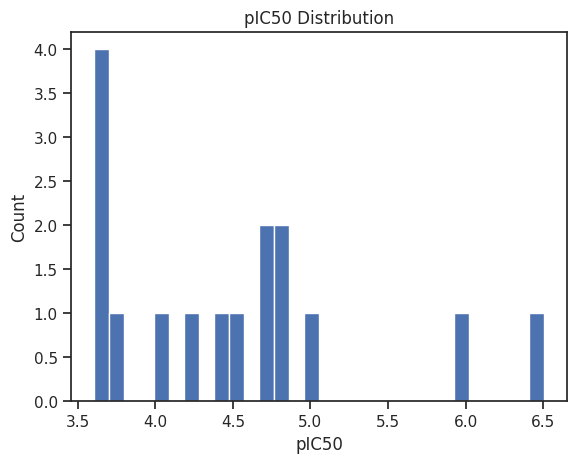

<Figure size 640x480 with 0 Axes>

In [33]:
plt.hist(df_clean["pIC50"], bins=30)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("pIC50 Distribution")
plt.show()
plt.savefig('histogram_pic50.pdf')

Text(0, 0.5, 'Frequency')

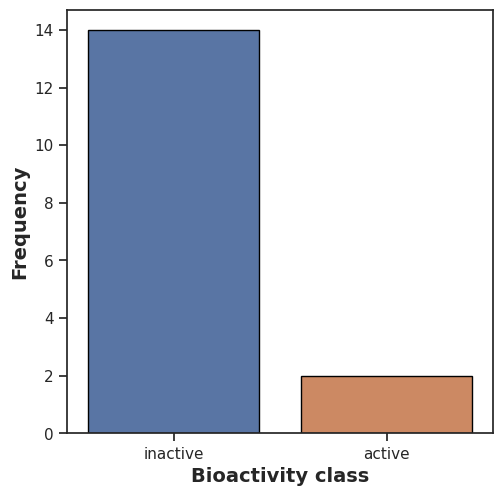

In [34]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_clean, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

# **Lipinski's Descriptor Calculation**

## **Install rdkit**

In [35]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 50.5 MB/s eta 0:00:00


In [36]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors

In [37]:
df_no_smiles = df_clean.drop(columns='canonical_smiles')

smiles = []

for i in df_clean.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key=len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name='canonical_smiles')

df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)

df_clean_smiles

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL1784772,52800.0,inactive,4.277366,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...
1,CHEMBL1784771,250000.0,inactive,3.602060,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...
2,CHEMBL1784781,250000.0,inactive,3.602060,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
3,CHEMBL1784770,35000.0,inactive,4.455932,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
4,CHEMBL1784777,18400.0,inactive,4.735182,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
5,CHEMBL1784775,30100.0,inactive,4.521434,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
6,CHEMBL1784779,14900.0,inactive,4.826814,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
7,CHEMBL2369531,17700.0,inactive,4.752027,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
8,CHEMBL2369532,171700.0,inactive,3.765230,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
9,CHEMBL1784784,1000.0,active,6.000000,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...


## **Calculate descriptors**

In [38]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors


In [39]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,577.591,-2.2640,7.0,8.0
1,533.582,-1.5747,6.0,7.0
2,567.536,-1.2048,5.0,7.0
3,541.498,-1.6911,6.0,7.0
4,583.579,-0.6649,6.0,7.0


In [40]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,577.591,-2.2640,7.0,8.0
1,533.582,-1.5747,6.0,7.0
2,567.536,-1.2048,5.0,7.0
3,541.498,-1.6911,6.0,7.0
4,583.579,-0.6649,6.0,7.0


In [41]:
df_lipinski.shape

(16, 4)

Combine Both datasets

In [42]:
df_clean_smiles.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL1784772,52800.0,inactive,4.277366,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...
1,CHEMBL1784771,250000.0,inactive,3.602060,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...
2,CHEMBL1784781,250000.0,inactive,3.602060,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
3,CHEMBL1784770,35000.0,inactive,4.455932,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...
4,CHEMBL1784777,18400.0,inactive,4.735182,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...


In [43]:
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,577.591,-2.2640,7.0,8.0
1,533.582,-1.5747,6.0,7.0
2,567.536,-1.2048,5.0,7.0
3,541.498,-1.6911,6.0,7.0
4,583.579,-0.6649,6.0,7.0


In [44]:
df_combined = pd.concat([df_clean_smiles, df_lipinski], axis=1)
df_combined.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1784772,52800.0,inactive,4.277366,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...,577.591,-2.2640,7.0,8.0
1,CHEMBL1784771,250000.0,inactive,3.602060,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...,533.582,-1.5747,6.0,7.0
2,CHEMBL1784781,250000.0,inactive,3.602060,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,567.536,-1.2048,5.0,7.0
3,CHEMBL1784770,35000.0,inactive,4.455932,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,541.498,-1.6911,6.0,7.0
4,CHEMBL1784777,18400.0,inactive,4.735182,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,583.579,-0.6649,6.0,7.0


In [45]:
df_combined = df_combined.drop(columns="standard_value")
df_combined.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1784772,inactive,4.277366,CC(=O)N[C@@H](CC(C(=O)O)C(=O)O)C(=O)N1CCC[C@H]...,577.591,-2.2640,7.0,8.0
1,CHEMBL1784771,inactive,3.602060,CC(=O)N[C@@H](CCC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[...,533.582,-1.5747,6.0,7.0
2,CHEMBL1784781,inactive,3.602060,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,567.536,-1.2048,5.0,7.0
3,CHEMBL1784770,inactive,4.455932,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,541.498,-1.6911,6.0,7.0
4,CHEMBL1784777,inactive,4.735182,CC(=O)N[C@@H](COP(=O)(O)O)C(=O)N1CCC[C@H]1C(=O...,583.579,-0.6649,6.0,7.0


In [46]:
# Save CSV
df_combined.to_csv("df_lipinski.csv", index=False)

## **Exploratory Data Analysis or Chemical Space Analysis For Lipinski Descriptors**

## **Barplot of the bioactivity classes**

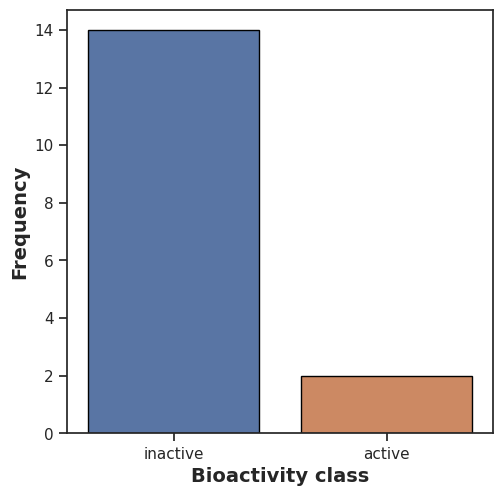

In [47]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_combined, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('barplot_bioactivity_class.pdf')

## **Boxplot of the bioactivity classes for PIC50**

Text(0, 0.5, 'pIC50 value')

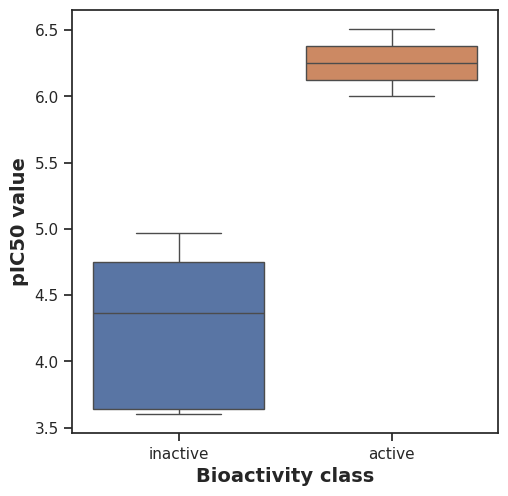

In [48]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "pIC50", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

## **Scatter of Molecular Weight vs Solubility (LogP)**

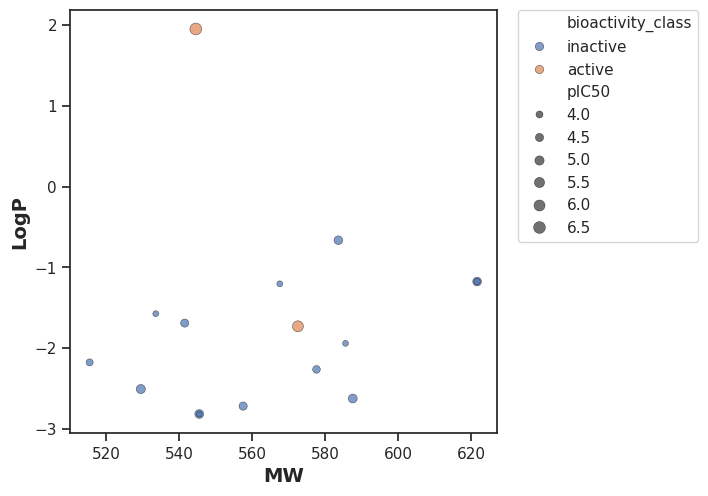

In [49]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_combined, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('scatter_plot_MW_vs_LogP.pdf')

## **Statistical analysis (Mann-Whitney U Test)**

In [50]:
def mannwhitney(descriptor, df_combined, verbose=False):
    """
    Perform Mann-Whitney U test between active and inactive compounds
    for a given descriptor.

    Parameters:
    - descriptor : str, column name of the descriptor
    - df_combined : pandas DataFrame, must have columns [descriptor, bioactivity_class]
    - verbose : bool, if True prints the test statistics

    Returns:
    - results : pandas DataFrame with test statistics, p-value, and interpretation
    """
    from numpy.random import seed
    from scipy.stats import mannwhitneyu
    import pandas as pd

    # set seed for reproducibility
    seed(1)

    # select only relevant columns
    df = df_combined[[descriptor, 'bioactivity_class']]

    # separate active and inactive compounds
    active = df[df['bioactivity_class'] == 'active'][descriptor]
    inactive = df[df['bioactivity_class'] == 'inactive'][descriptor]

    # perform Mann-Whitney U test
    stat, p = mannwhitneyu(active, inactive)

    if verbose:
        print(f"Descriptor: {descriptor}")
        print(f"Statistics={stat:.3f}, p={p:.3f}")

    # interpret result
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    # store results in a DataFrame
    results = pd.DataFrame({
        'Descriptor': descriptor,
        'Statistics': stat,
        'p': p,
        'alpha': alpha,
        'Interpretation': interpretation
    }, index=[0])

    # save results to CSV
    filename = 'mannwhitneyu_' + descriptor + '.csv'
    results.to_csv(filename, index=False)

    return results

# **pIC50**

In [51]:
mannwhitney("pIC50", df_combined, verbose=True)

Descriptor: pIC50
Statistics=28.000, p=0.031


,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,28.0,0.030817,0.05,Different distribution (reject H0)


# **Molecular Weight**


In [52]:
mannwhitney("MW", df_combined, verbose=True)

Descriptor: MW
Statistics=12.000, p=0.812


,Descriptor,Statistics,p,alpha,Interpretation
0,MW,12.0,0.811617,0.05,Same distribution (fail to reject H0)


# **Solubility LogP**

In [53]:
mannwhitney("LogP", df_combined, verbose=True)

Descriptor: LogP
Statistics=22.000, p=0.233


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,22.0,0.233378,0.05,Same distribution (fail to reject H0)


# **Number of Hydrogen Donors**

In [54]:
mannwhitney("NumHDonors", df_combined, verbose=True)

Descriptor: NumHDonors
Statistics=10.000, p=0.548


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,10.0,0.548049,0.05,Same distribution (fail to reject H0)


# **Number of Hydrogen Acceptors**

In [55]:
mannwhitney("NumHAcceptors", df_combined, verbose=True)

Descriptor: NumHAcceptors
Statistics=9.000, p=0.423


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,9.0,0.422678,0.05,Same distribution (fail to reject H0)


# **Combine All Statistical Results**

In [56]:
import pandas as pd
import glob
import os

# Get list of all Mann-Whitney CSV files in current folder
mw_files = glob.glob("mannwhitneyu_*.csv")

# Combine them into one DataFrame
mw_combined = pd.concat([pd.read_csv(f) for f in mw_files], ignore_index=True)

# Save combined CSV
combined_filename = "mannwhitney_summary.csv"
mw_combined.to_csv(combined_filename, index=False)

print(f"Combined Mann-Whitney CSV saved as {combined_filename}")

Combined Mann-Whitney CSV saved as mannwhitney_summary.csv


## **Molecular Weight**

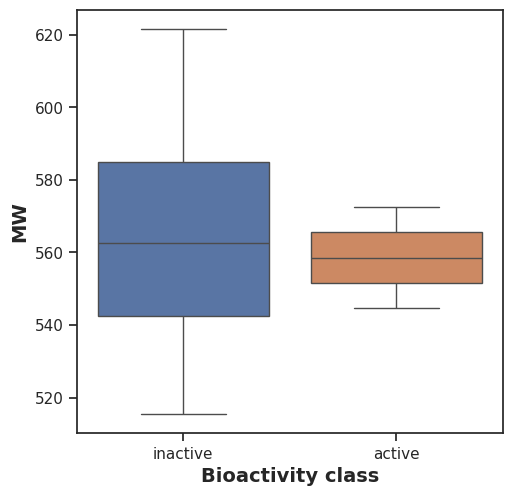

In [57]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('boxplot_MW.pdf')


## **logP**

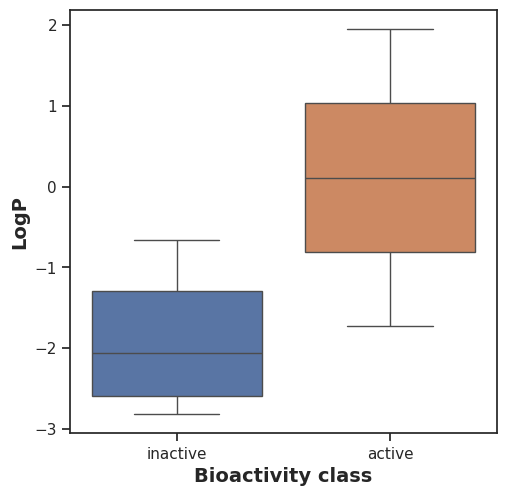

In [58]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = 'LogP', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('boxplot_LogP.pdf')

## **NumHDonors**

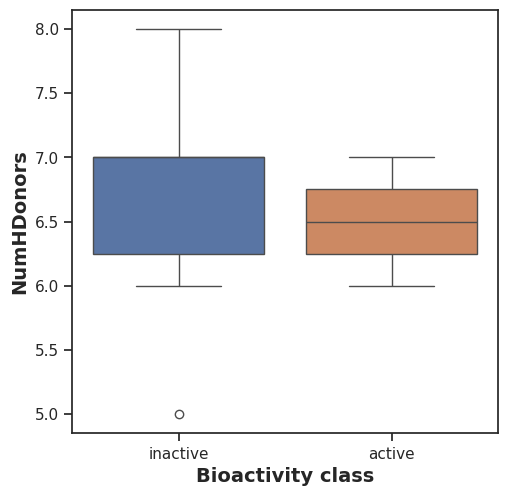

In [59]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHDonors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHDonors.pdf')

## **NumHAcceptors**

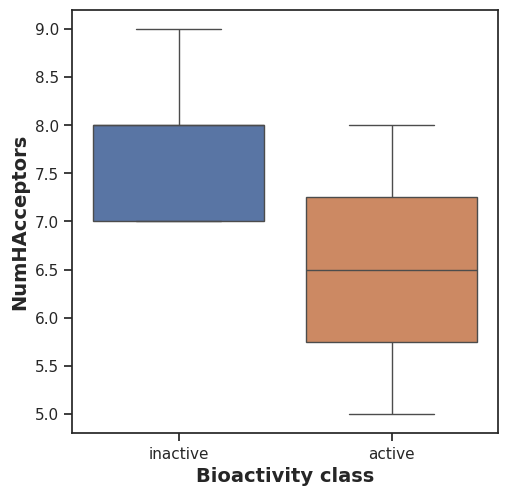

In [60]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHAcceptors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHAcceptors.pdf')

## **Save & Downlaod Results**

In [61]:
! zip -r EDA_results.zip . -i *df_lipinski.csv *mannwhitney_summary.csv *.pdf

  adding: boxplot_NumHAcceptors.pdf (deflated 37%)
  adding: mannwhitney_summary.csv (deflated 50%)
  adding: boxplot_MW.pdf (deflated 38%)
  adding: boxplot_NumHDonors.pdf (deflated 37%)
  adding: df_lipinski.csv (deflated 75%)
  adding: scatter_plot_MW_vs_LogP.pdf (deflated 28%)
  adding: boxplot_LogP.pdf (deflated 39%)
  adding: histogram_pic50.pdf (deflated 49%)
  adding: barplot_bioactivity_class.pdf (deflated 38%)
